# Module 1: Simply Fully Connected Networks for Image Classification
     - Build a small FC network in PyTorch
     - Understand train/validation/test splits
     - See overfitting empirically
     - Understand generalization, distribution shift, inductive bias


In [1]:
# Add src/ to the path so we can import utility functions
import sys
sys.path.append("./src")

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from utils import (
    get_mnist_loaders,
    show_examples,
    plot_loss_curves,
    show_predictions,
    preprocess_drawn_digit,
    predict_drawn_digit,
    show_drawn_digit_prediction,
    make_drawing_canvas,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Loss function: Cross-Entropy

<!-- Pointer: explain Cross-Entropy Loss for K-class classification.
     - Output layer produces K logits (one per class)
     - Softmax converts logits to probabilities
     - CE loss = -log(probability of correct class)
     - Mention BCE briefly: special case for binary classification (K=2)
     - In PyTorch, nn.CrossEntropyLoss combines softmax + NLL for numerical stability
       so the model outputs raw logits, NOT softmax probabilities.
-->

## 1. The data

<!-- Pointer: introduce MNIST.
     - 60,000 training + 10,000 test, 28x28 grayscale images of digits 0-9
     - We will further split the training set into train + validation
     - Why: train = update parameters; val = monitor overfitting; test = final unseen evaluation
     - Stress: never tune anything based on test performance!
-->

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.91MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 296kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.97MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.94MB/s]


Train batches: 422  (54000 examples)
Val batches:   47  (6000 examples)
Test batches:  79  (10000 examples)


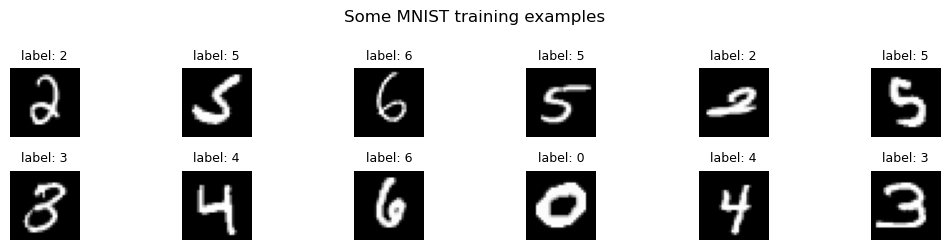

In [2]:
train_loader, val_loader, test_loader = get_mnist_loaders(
    batch_size=128,
    val_fraction=0.1,
    train_subset_size=None,   # <-- set to e.g. 1000 to deliberately induce overfitting
    seed=0,
)

print(f"Train batches: {len(train_loader)}  ({len(train_loader.dataset)} examples)")
print(f"Val batches:   {len(val_loader)}  ({len(val_loader.dataset)} examples)")
print(f"Test batches:  {len(test_loader)}  ({len(test_loader.dataset)} examples)")

show_examples(train_loader, n=12, title="Some MNIST training examples")

## 2. Build a fully connected network

<!-- Pointer: introduce PyTorch model definition.
     - Subclass nn.Module
     - Define layers in __init__
     - Define the forward pass in forward()
     - Input is [batch, 1, 28, 28]; flatten to [batch, 784] before FC
     - Output is [batch, 10] raw logits
-->

### 2a. Hyperparameters

<!-- Pointer: tell students these are the knobs they will turn to study overfitting.
     Increasing hidden_size or num_layers or epochs while shrinking train_subset_size
     should make overfitting appear.
-->

In [ ]:
# ----- Knobs you can change -----
INPUT_DIM    = 28 * 28   # MNIST images flattened
HIDDEN_SIZE  = 128       # try 32, 128, 1024
NUM_HIDDEN   = 1         # try 1, 2, 4
OUTPUT_DIM   = 10        # 10 digit classes

LEARNING_RATE = 1e-3
NUM_EPOCHS    = 10       # try 5, 20, 50
BATCH_SIZE    = 128      # already used in the loaders above
# --------------------------------

### 2b. The model class

<!-- Pointer: students fill in the layer definitions and forward pass.
     Show them the class skeleton; the TODOs scope what they have to do.
-->

In [ ]:
class FCNet(nn.Module):
    def __init__(self, input_dim, hidden_size, num_hidden, output_dim):
        super().__init__()
        # TODO: Build a list of layers.
        # Hint: input_dim -> hidden_size, then num_hidden-1 hidden->hidden layers,
        #       then hidden_size -> output_dim. ReLU between layers, no activation on the output.
        # Tip: use nn.Sequential or nn.ModuleList.
        layers = []
        # ...
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # x has shape [batch, 1, 28, 28]
        # TODO:
        # 1. Flatten x to shape [batch, 784]
        # 2. Pass it through self.net
        # 3. Return raw logits (do NOT apply softmax here -- CrossEntropyLoss expects logits)
        pass


# Quick sanity check (uncomment after filling in the class):
# model = FCNet(INPUT_DIM, HIDDEN_SIZE, NUM_HIDDEN, OUTPUT_DIM).to(device)
# x_dummy, _ = next(iter(train_loader))
# out = model(x_dummy.to(device))
# print("Output shape:", out.shape)        # expect [batch, 10]
# print("Parameters:", sum(p.numel() for p in model.parameters()))

### 2c. Training loop

<!-- Pointer: walk through the standard PyTorch training loop.
     - For each epoch, iterate over batches
     - For each batch: zero gradients, forward, loss, backward, step
     - At end of each epoch, evaluate on validation set with model.eval() and torch.no_grad()
     - Track train/val loss and accuracy each epoch -> plot at the end
-->

In [ ]:
def evaluate(model, loader, criterion, device):
    """Compute average loss and accuracy on a dataloader."""
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n


# Build the model, loss, optimizer
model = FCNet(INPUT_DIM, HIDDEN_SIZE, NUM_HIDDEN, OUTPUT_DIM).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(1, NUM_EPOCHS + 1):
    # TODO: training loop for this epoch
    # for x, y in train_loader:
    #     1. move x, y to device
    #     2. zero gradients on the optimizer
    #     3. forward pass
    #     4. compute loss
    #     5. backward pass
    #     6. optimizer step
    pass  # remove once filled in

    # Evaluate at end of epoch
    train_loss, train_acc = evaluate(model, train_loader, criterion, device)
    val_loss,   val_acc   = evaluate(model, val_loader,   criterion, device)

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc);    val_accs.append(val_acc)

    print(f"Epoch {epoch:>2}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
          f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")

## 3. Evaluation

<!-- Pointer: this is where the conceptual content lives.
     - Plot loss curves: training loss going to zero while val loss flattens or rises = overfitting
     - Generalization gap = val_loss - train_loss
     - Encourage students to retrain with HIDDEN_SIZE much larger or train_subset_size much smaller and re-plot
     - Compare loss curves before/after
-->

In [ ]:
plot_loss_curves(train_losses, val_losses, train_accs, val_accs)

### Test set evaluation

<!-- Pointer: this is the *single* evaluation you do once you're done training.
     - Should be done only once per model you settle on
     - If test acc << val acc you may have inadvertently tuned on val
-->

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f}   Test accuracy: {test_acc:.3f}")

# Show some example predictions (mix of correct and wrong)
show_predictions(model, test_loader, device, n=12, only_wrong=False)

# Show only mistakes
show_predictions(model, test_loader, device, n=12, only_wrong=True)

## 4. Distribution shift: hand-drawn digits

<!-- Pointer: this is the punchline of the module.
     - Even a model that gets 98% test accuracy on MNIST may struggle on hand-drawn digits
     - Why: pencil strokes, centering, image size, contrast all differ from MNIST
     - This is *distribution shift*: the test data comes from a different distribution than train
     - Connect to inductive bias: a model that just learns pixel patterns won't generalize as well
       as a model with appropriate priors (foreshadow CNN module)
-->

###  Draw in Paint, save as PNG, upload here
Save as a PNG (any size), put it in the notebook directory, point the path here.

In [ ]:
# Edit this path to your saved PNG
image_path = "my_digit.png"

pred, probs = predict_drawn_digit(model, image_path, device)
show_drawn_digit_prediction(image_path, pred, probs)

## 5. Exercise: induce overfitting on purpose

<!-- Pointer: this is the active learning piece.
     Suggested experiments:
       1. Reduce train_subset_size to 500 in get_mnist_loaders. Train for 50 epochs. What happens?
       2. Increase HIDDEN_SIZE to 2048 with full data. Compare loss curves to the smaller model.
       3. Stack 5+ hidden layers. What happens to training stability and overfitting?
       4. After each experiment, run the hand-drawn digit test. Which model generalizes best?
     Discussion to lead into next module:
       - FC has very weak inductive bias for images
       - Even with regularization tricks (we haven't used any), the FC has no clue about
         neighboring pixels being related
       - That motivates the CNN -- next module
-->